# Building Neutron Stars: Equation of State and TOV Equations

## 1. Hydrostatic Equilibrium in General Relativity: TOV Equations

Newtonian hydrostatic equilibrium is inadequate for describing neutron stars, since they are highly compact, relativistic objects in which strong gravity significantly alters the spacetime geometry and the relation between pressure, energy density, and gravity must be treated within general relativity. 

The structure of neutron stars is encapsulated in the so-called TOV equations, named after Tolman, Oppenheimer and Volkov. These equations represent the generalization of Newtonian gravity to the domain of general relativity. The gross properties of a neutron star can be determined under the assumption that the star has a spherically symmetric mass distribution on hydrostatic equilibrium and that the star is extremely cold $T=0 \ \rm{(K)}$.
The TOV equation is given by the formula:

\begin{equation}
\frac{dP(r)}{dr}
=
-\frac{G m(r)\,\rho(r)}{r^2}
\color{blue}{\left(1+\frac{P(r)}{\rho(r)c^2}\right)
\left(1+\frac{4\pi r^3 P(r)}{m(r)c^2}\right)
\left(1-\frac{2Gm(r)}{rc^2}\right)^{-1}}.
\end{equation}

The mass function satisfies:
\begin{equation}
\frac{dm(r)}{dr} = 4\pi r^2 \varepsilon(r)/c^2,
\end{equation}

where $\varepsilon(r)$ is the energy density.

To close the system, one must specify an equation of state (EOS), which relates pressure and energy density:
\begin{equation}
P = P(\varepsilon),
\end{equation}

or in the case of a polytropic EOS:
\begin{equation}
P = K \varepsilon^\Gamma.
\end{equation}


The three additional terms of the TOV equation are corrections from general relativity:

- The first correction term modifies the mass density $\rho$ and takes into account that gravity couples to the energy density $\varepsilon(r)$ and the pressure $P(r)$ of matter.
- The second correction term modifies the mass
  function $m(r)$ and adds another correction term from the pressure of matter.
- Lastly, the third correction term modifies the radius, considering the warpage of spacetime described by the Schwarzschild factor.


### Scaling of the TOV Equations

Our initial step involves the transformation of the TOV equations, tailoring them to ensure their compatibility with numerical integration techniques. This critical process is essential for effectively leveraging computational methods in our analysis. We define the energy density in $\rm (MeV \cdot fm^{-3})$ units, the mass in $M_{\odot}$ and the radius in $\rm (km)$. The modified TOV Equations read:

\begin{align}
\frac{d \bar{P}(r)}{dr} &= -1.474\frac{\bar{\varepsilon}(r) \bar{m}_r (r)}{r^2} \left(1+\frac{\bar{P}(r)}{\bar{\varepsilon}(r)}\right) \left(1+ \frac{11.2 r^3}{10^6} \frac{\bar{P}(r)}{\bar{m}_r(r)}\right) \left(1-2.948\frac{\bar{m}_r(r)}{ r}\right)^{-1} \notag \\
\frac{d \bar{m}_r(r)}{dr} &= 11.2 \cdot 10^{-6}r^2 \bar{\varepsilon}(r),
\end{align}
where:
\begin{align}
    m_r(r) &= \bar{m}_r(r)M_{\odot} \notag\\
    \varepsilon(r) &= \bar{\varepsilon}(r)\varepsilon_o \notag\\
    P(r) &= \bar{P}(r)\varepsilon_o \notag\\
    \varepsilon_o &= 1 \ \left( \rm{MeV \cdot fm^{-3}} \right) \\
    \frac{GM_{\odot}}{c^2}&=1.474 \ \rm{(km)} \notag\\
    \frac{4\pi}{M_{\odot}c^2} &= 0.7 \cdot 10^{-40} \left( \rm{s^2 \cdot kg^{-1} \cdot km^{-2}}\right) \notag
\end{align}

### Numerical Solution

We employ numerical methods to solve the modified system of TOV equations, incorporating equations of state in the form $\varepsilon(P)$. To prevent division by zero, we set boundary conditions to be exceedingly small and not exacty zero $(r_{center} \rightarrow 0 \text{ and } m_{center} \rightarrow 0)$. The differential equations system is then solved for central pressure values $P_c$ ranging from $1$ to  $1000 \ (\rm{MeV \cdot fm^{-3}})$, which serve as boundary conditions. From the resulting solution, we obtain values for mass $M$ and radius $R$. Using these values, we construct mass-radius (M-R) diagrams corresponding to each EOS utilized. We implement the numerical solution using the fourth-order Runge-Kutta method, defined by the following formulas:
\begin{equation}
    \frac{dP}{dr}=f(r,P,m;\varepsilon) \quad\quad \frac{dm_r}{dr}=g(r,P,m;\varepsilon),
\end{equation}
where $\varepsilon=\varepsilon(P)$ was added as a parameter function. In each iteration, the values of $P$ and $m$ will change as:
\begin{align}
    P_{n+1} &= P_n + \frac{1}{6}(k_1 + 2 k_2 + 2 k_3 + k_4), \\
    m_{n+1} &= m_n + \frac{1}{6}(l_1 + 2 l_2 + 2 l_3 + l_4),
\end{align}
where:
\begin{align}
    k_1 &= h f(r_n, P_n, m_n; \varepsilon) & l_1 &= h g(r_n, P_n, m_n; \varepsilon) \notag \\   
    k_2 &= h f(r_n+\frac{h}{2}, P_n+\frac{k_1}{2}, m_n+\frac{l_1}{2}; \varepsilon) & l_2 &= h g(r_n+\frac{h}{2}, P_n+\frac{k_1}{2}, m_n+\frac{l_1}{2}; \varepsilon) \notag \\    
    k_3 &= h f(r_n+\frac{h}{2}, P_n+\frac{k_2}{2}, m_n+\frac{l_2}{2}; \varepsilon) & l_3 &= h g(r_n+\frac{h}{2}, P_n+\frac{k_2}{2}, m_n+\frac{l_2}{2}; \varepsilon) \notag \\  
    k_4 &= h f(r_n+h, P_n+k_3, m_n+l_3; \varepsilon) & l_4 &= h g(r_n+h, P_n+k_3, m_n+l_3; \varepsilon), \notag
\end{align}
in which $h$ is the step of the iteration, defined by:
\begin{equation}
    h=\frac{r_{end}-r_{center}}{N},
\end{equation}
where $N$ is the number of points the radial space was divided. The integration stops when the pressure becomes (practically) zero, which means that we have reached the surface of the star.

## 2. Code

In [1]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# from scipy.interpolate import PchipInterpolator


# Define the radial grid and range
r_start = 1.0e-10
r_end = 20.0
num_points = 10000 
r_values = np.linspace(r_start, r_end, num_points)
hbarc = 197.327

# Step for numerical solution
step = (r_end - r_start) / num_points

### Define the EOS

#### a) Crust

In [2]:
def h_crust1(P):
    if P < 0:
        P = 0
    result = 0.00873 + 103.17338*(1-np.exp(-P/0.38527)) + 7.34979*(1-np.exp(-P/0.01211))
    return result

def h_crust2(P): #EOS for P between (4.1725e-8, 9.34375e-5)
    if P < 0:
        P = 0
    result = 0.00015 + 0.00203*(1-np.exp(-P*344827.5)) + 0.10851*(1-np.exp(-P*7692.3076))
    return result


def h_crust3(P): #EOS for P between (1.44875e-11, 4.1725e-8)
    if P < 0:
        P = 0
    result = 0.0000051*(1-np.exp(-P*0.2373e10)) + 0.00014*(1-np.exp(-P*0.4020e8))
    return result

#### b) Core - Hadronic EOS

In [16]:
def h_MDI1_func(P):
    if P < 0:
        P = 0
    result = (4.1844*(P**0.81449)) + (95.00135*(P**0.31736))
    return result

def h_MDI2_func(P):
    if P < 0:
        P = 0
    result = (5.97365 * (P ** 0.77374)) + (89.24 * (P ** 0.30993))
    return result

def h_MDI3_func(P):
    if P < 0:
        P = 0
    result = (15.55 * (P ** 0.666)) + (76.71 * (P ** 0.247))
    return result

def h_MDI4_func(P):
    if P < 0:
        P = 0
    result = (25.99587 * (P ** 0.61209)) + (65.62193 * (P ** 0.15512))
    return result

def h_NLD_func(P):
    if P < 0:
        P = 0
    result = 119.05736 + 304.80445 *(1-np.exp(-P/48.61465)) + 33722.34448 *(1-np.exp(-P/17499.47411))
    return result

def h_HHJ1_func(P):
    if P < 0:
        P = 0
    result = (1.78429 * (P ** 0.93761)) + (106.93652 * (P ** 0.31715))
    return result

def h_HHJ2_func(P):
    if P < 0:
        P = 0
    result = (1.18961 * (P ** 0.96539)) + (108.40302 * (P ** 0.31264))
    return result

def h_Ska_func(P):
    if P < 0:
        P=0
    result = (0.53928 * (P ** 1.01394)) + (94.31452 * (P ** 0.35135))
    return result

def h_Sk14_func(P):
    if P < 0:
        P = 0
    result = (4.75668 * (P ** 0.76537)) + (105.722 * (P ** 0.2745))
    return result

def h_HLPS2_func(P):
    if P < 0:
        P = 0
    result = 172.858*(1-np.exp(-P/22.8644)) + 2777.75*(1-np.exp(-P/1909.97)) + 161.553
    return result

def h_SCVBB_func(P):
    if P < 0:
        P = 0
    result = (0.371414 * (P ** 1.08004)) + (109.258 * (P ** 0.351019))
    return result

def h_W_func(P):
    if P < 0:
        P = 0
    result = (0.261822 * (P ** 1.16851)) + (92.4893 * (P ** 0.307728))
    return result

def h_BGP_func(P):
    if P < 0:
        P = 0
    result = (0.0112475 * (P ** 1.59689)) + (102.302 * (P ** 0.335526))
    return result
    
def h_BL1_func(P):
    if P < 0:
        P = 0
    result = (0.488686 * (P ** 1.01457)) + (102.26 * (P ** 0.355095))
    return result
    
def h_BL2_func(P):
    if P < 0:
        P = 0
    result = (1.34241 * (P ** 0.910079)) + (100.756 * (P ** 0.354129))
    return result
    
def h_DH_func(P):
    if P < 0:
        P = 0
    result = (39.5021 * (P ** 0.541485)) + (96.0528 * (P ** 0.00401285))
    return result
        
def h_APR1_func(P):
    if P < 0:
        P = 0
    result = (0.000719964 * (P ** 1.85898)) + (108.975 * (P ** 0.340074))
    return result

#### c) CompOSE database - Tabulated EOS

All the EOS above are in the analytic form of:

\begin{equation}
\varepsilon = \sum_i A_i P^{a_i},
\end{equation}

which can be interpreted as a piecewise-polytropic or multi-polytropic representation of the equation of state. In practise, we use EOS in a tabular form. Tabulated EOS can be found e.g. in the [CompOSE database](https://compose.obspm.fr/home/) (CompStar Online Supernovae Equations of State). 

To access the EOS calculator on the website, an account is required. This can be created by directly contacting their team, after which access will be granted.

### Observational constraints (optional)

In [4]:
HESS_R_1sigma = []
HESS_M_1sigma = []
HESS_R_2sigma = []
HESS_M_2sigma = []

J12_R_1sigma = []
J12_M_1sigma = []
J12_R_2sigma = []
J12_M_2sigma = []

XTE_R_1sigma = []
XTE_M_1sigma = []
XTE_R_2sigma = []
XTE_M_2sigma = []

J030_R_1sigma = []
J030_M_1sigma = []
J030_R_2sigma = []
J030_M_2sigma = []

J04_R_1sigma = []
J04_M_1sigma = []
J04_R_2sigma = []
J04_M_2sigma = []

J07_R_1sigma = []
J07_M_1sigma = []
J07_R_2sigma = []
J07_M_2sigma = []

GW17_R_M1 = []
GW17_M_M1 = []
GW17_R_M2 = []
GW17_M_M2 = []

with open('HESS_J1731-347_1sigma.txt', 'r') as file:
    next(file)
    for line in file:
        values = line.split( )
        HESS_R_1sigma.append(float(values[0]))  
        HESS_M_1sigma.append(float(values[1]))

with open('HESS_J1731-347_2sigma.txt', 'r') as file:
    next(file)
    for line in file:
        values = line.split( ) 
        HESS_R_2sigma.append(float(values[0]))  
        HESS_M_2sigma.append(float(values[1]))

with open('J1231_R21_68.txt', 'r') as file:
    for line in file:
        values = line.split( ) 
        J12_R_1sigma.append(float(values[0]))  
        J12_M_1sigma.append(float(values[1]))

with open('J1231_R21_95.txt', 'r') as file:
    for line in file:
        values = line.split( ) 
        J12_R_2sigma.append(float(values[0]))  
        J12_M_2sigma.append(float(values[1]))

with open('J1814-338_68.txt', 'r') as file:
    for line in file:
        values = line.split( ) 
        XTE_R_1sigma.append(float(values[0]))  
        XTE_M_1sigma.append(float(values[1]))

with open('J1814-338_95.txt', 'r') as file:
    for line in file:
        values = line.split( ) 
        XTE_R_2sigma.append(float(values[0])) 
        XTE_M_2sigma.append(float(values[1]))


with open('J0437_68.txt', 'r') as file:
    for line in file:
        values = line.split( ) 
        J04_R_1sigma.append(float(values[0])) 
        J04_M_1sigma.append(float(values[1]))

with open('J0437_95.txt', 'r') as file:
    for line in file:
        values = line.split( ) 
        J04_R_2sigma.append(float(values[0])) 
        J04_M_2sigma.append(float(values[1]))

with open('J0030_NICER_68.txt', 'r') as file:
    for line in file:
        values = line.split( ) 
        J030_R_1sigma.append(float(values[0]))  
        J030_M_1sigma.append(float(values[1]))

with open('J0030_NICER_95.txt', 'r') as file:
    for line in file:
        values = line.split( ) 
        J030_R_2sigma.append(float(values[0]))  
        J030_M_2sigma.append(float(values[1]))

with open('J0740_68.txt', 'r') as file:
    for line in file:
        values = line.split( )
        J07_R_1sigma.append(float(values[0])) 
        J07_M_1sigma.append(float(values[1]))

with open('J0740_95.txt', 'r') as file:
    for line in file:
        values = line.split( ) 
        J07_R_2sigma.append(float(values[0])) 
        J07_M_2sigma.append(float(values[1]))

with open('GW170817_m1.txt', 'r') as file:
    for line in file:
        values = line.split( ) 
        GW17_R_M1.append(float(values[0]))  
        GW17_M_M1.append(float(values[1]))

with open('GW170817_m2.txt', 'r') as file:
    for line in file:
        values = line.split( ) 
        GW17_R_M2.append(float(values[0]))  
        GW17_M_M2.append(float(values[1]))

### TOV Equations (pressure, mass, radius, equation of state)

In [5]:
def tov_equations(r, u, h_func):
    P, m = u
    h = h_func(P)

    # Check for division by zero
    if r == 0 or h == 0 or m == 0:
        dP_dr = 0.0
        dm_dr = 0.0
    else:
        dP_dr = -1.474 * h * m / (r**2) * (1 + P / h) * (1 + 11.2e-6 * (r**3) * P / m) * (1 - 2.948 * m / r)**(-1)
        dm_dr = 11.2e-6 * (r**2) * h

    return [dP_dr, dm_dr]

### Numerical solution using Runge Kutta

In [6]:
def solve_runge_kutta(P0, h_func, Q):
    m0 = 1.0e-10  #Avoid division by zero
    P = P0
    m = m0

# Runge-Kutta 4th order
    for i in range(1, num_points):
        r = r_values[i]
        u = [P, m]

        if Q<0:
            if P > 1e-11:
                k1 = np.multiply(step, tov_equations(r, u, h_func))
                k2 = np.multiply(step, tov_equations(r + 0.5 * step, np.add(u, 0.5 * k1), h_func))
                k3 = np.multiply(step, tov_equations(r + 0.5 * step, np.add(u, 0.5 * k2), h_func))
                k4 = np.multiply(step, tov_equations(r + step, np.add(u, k3), h_func))

            else:
                # Pressure is zero or negative
                return [r, m]

        if Q>0: 
            if P >= 0.184:
                k1 = np.multiply(step, tov_equations(r, u, h_func))
                k2 = np.multiply(step, tov_equations(r + 0.5 * step, np.add(u, 0.5 * k1), h_func))
                k3 = np.multiply(step, tov_equations(r + 0.5 * step, np.add(u, 0.5 * k2), h_func))
                k4 = np.multiply(step, tov_equations(r + step, np.add(u, k3), h_func))
        
            elif P > 9.34375e-5:
                k1 = np.multiply(step, tov_equations(r, u, h_crust1))
                k2 = np.multiply(step, tov_equations(r + 0.5 * step, np.add(u, 0.5 * k1), h_crust1))
                k3 = np.multiply(step, tov_equations(r + 0.5 * step, np.add(u, 0.5 * k2), h_crust1))
                k4 = np.multiply(step, tov_equations(r + step, np.add(u, k3), h_crust1))
           
            elif P > 4.1725e-8:
                k1 = np.multiply(step, tov_equations(r, u, h_crust2))
                k2 = np.multiply(step, tov_equations(r + 0.5 * step, np.add(u, 0.5 * k1), h_crust2))
                k3 = np.multiply(step, tov_equations(r + 0.5 * step, np.add(u, 0.5 * k2), h_crust2))
                k4 = np.multiply(step, tov_equations(r + step, np.add(u, k3), h_crust2))
                
            elif P > 1e-11 :
                k1 = np.multiply(step, tov_equations(r, u, h_crust3))
                k2 = np.multiply(step, tov_equations(r + 0.5 * step, np.add(u, 0.5 * k1), h_crust3))
                k3 = np.multiply(step, tov_equations(r + 0.5 * step, np.add(u, 0.5 * k2), h_crust3))
                k4 = np.multiply(step, tov_equations(r + step, np.add(u, k3), h_crust3))
        
            else:
                # Pressure is zero or negative
                return [r, m]
        
        
        u_new = np.add(u, (k1 + 2.0 * k2 + 2.0 * k3 + k4) / 6.0)
          
        P, m = u_new
        
    return [r, m]

### Iteration for a range of initial pressures

In [11]:
def calculate_pressure_plot(h_func, Q):
    M_values = []
    R_values = []
    
    samplesCount = 25
    cP = np.geomspace(1,1000,samplesCount)
    print("Calculating values")
     
    for i, P0 in enumerate(cP):
        rAndM = solve_runge_kutta(P0, h_func, Q)
        if rAndM != None:
            R_values.append(rAndM[0])
            M_values.append(rAndM[1])
    return [R_values, M_values]     

### Plot

In [10]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def calculate_pressure_plot_animation(h_func, Q):
    M_values = []
    R_values = []

    samplesCount = 100 
    cP = np.geomspace(1, 1000, samplesCount)

    print("Calculating TOV solutions...")

    for P0 in cP:
        rAndM = solve_runge_kutta(P0, h_func, Q)
        if rAndM is not None:
            R_values.append(rAndM[0])
            M_values.append(rAndM[1])

    return np.array(cP[:len(R_values)]), np.array(R_values), np.array(M_values)


cP, R_values, M_values = calculate_pressure_plot_animation(h_DH_func, 1)



# Sort the central pressure (safety step)

idx = np.argsort(cP)
cP = cP[idx]
R_values = R_values[idx]
M_values = M_values[idx]

fig, ax = plt.subplots(figsize=(8, 6))

ax.set_xlabel(r'Radius $\rm{(km)}$',fontsize=22)
ax.set_ylabel(r'Mass $\rm (M_{\odot})$', fontsize=22)


ax.set_xlim(R_values.min()*0.5, R_values.max()*1.02)
ax.set_ylim(M_values.min()*0.9, M_values.max()*1.1)

line, = ax.plot([], [], 'o-', lw=1, markersize=4)

pressure_text = ax.text(
    0.5, 0.95, '',
    transform=ax.transAxes,
    verticalalignment='top', fontsize=20
)


def update(frame):
    line.set_data(R_values[:frame], M_values[:frame])
   
    pressure_text.set_text(rf"$P_c = {int(cP[frame])}\ \mathrm{{MeV\,fm^{{-3}}}}$")

    return line, pressure_text


anim = FuncAnimation(
    fig,
    update,
    frames=len(R_values),
    interval=150,
    blit=True
)

plt.close(fig)
HTML(anim.to_jshtml())

Calculating TOV solutions...


Calculating values
Calculating values
Calculating values
Calculating values
Calculating values
Calculating values
Rendering Plot


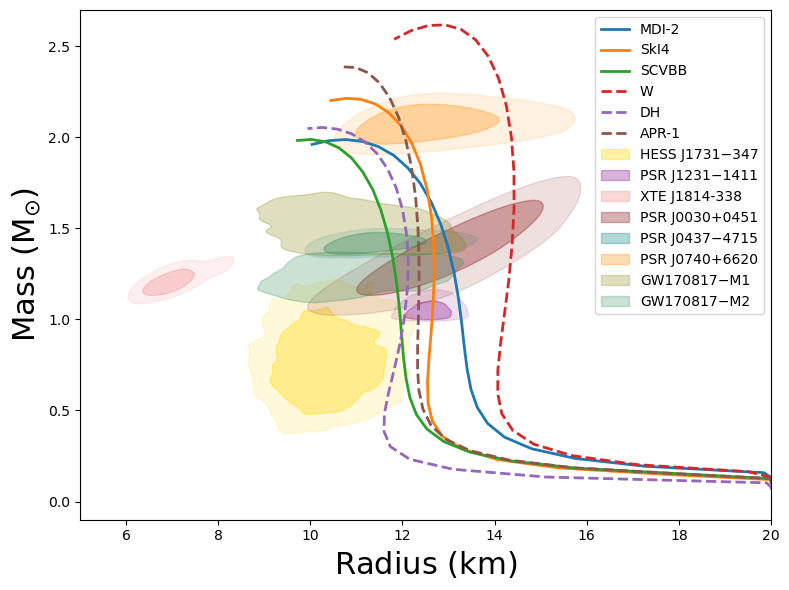

In [12]:
def render_plot(finalValues):
    
    print("Rendering Plot")
    fig, ax = plt.subplots(figsize=(8, 6)) 

    split_index = len(finalValues) // 2
    

    for i, rAndMValues in enumerate(finalValues):
        if i < split_index:
            linestyle = '-'
        else:
            linestyle = '--'
        ax.plot(rAndMValues[0], rAndMValues[1], linestyle=linestyle, lw=2)
    
    

    # HESS J1731-347
    plt.fill(HESS_R_2sigma, HESS_M_2sigma, alpha=0.15, color='gold', label='_nolegend_')
    plt.fill(HESS_R_1sigma, HESS_M_1sigma, alpha=0.35, color='gold', label='HESS J1731−347')
    
    # PSR J1231-1411
    plt.fill(J12_R_2sigma, J12_M_2sigma, alpha=0.12, color='purple', label='_nolegend_')
    plt.fill(J12_R_1sigma, J12_M_1sigma, alpha=0.30, color='purple', label='PSR J1231−1411')
    
    # XTE J1814-338
    plt.fill(XTE_R_2sigma, XTE_M_2sigma, alpha=0.12, color='lightcoral', label='_nolegend_')
    plt.fill(XTE_R_1sigma, XTE_M_1sigma, alpha=0.30, color='lightcoral', label='XTE J1814−338')
    
    # PSR J0030+0451
    plt.fill(J030_R_2sigma, J030_M_2sigma, alpha=0.12, color='maroon', label='_nolegend_')
    plt.fill(J030_R_1sigma, J030_M_1sigma, alpha=0.30, color='maroon', label='PSR J0030+0451')
    
    # J0437
    plt.fill(J04_R_2sigma, J04_M_2sigma, alpha=0.12, color='teal', label='_nolegend_')
    plt.fill(J04_R_1sigma, J04_M_1sigma, alpha=0.30, color='teal', label='PSR J0437−4715')
    
    # J0740
    plt.fill(J07_R_2sigma, J07_M_2sigma, alpha=0.12, color='darkorange', label='_nolegend_')
    plt.fill(J07_R_1sigma, J07_M_1sigma, alpha=0.30, color='darkorange', label='PSR J0740+6620')
    
    
    # GW170817
    plt.fill(GW17_R_M1, GW17_M_M1, color='olive', alpha=0.25, label='GW170817−M1')
    plt.fill(GW17_R_M2, GW17_M_M2, color='seagreen',alpha=0.25, label='GW170817−M2')
    plt.legend(['MDI-2', 'SkΙ4', 'SCVBB', 'W', 'DH', 'APR-1', 'HESS J1731−347', 'PSR J1231−1411', 
                'XTE J1814-338', 'PSR J0030+0451', 'PSR J0437−4715', 'PSR J0740+6620', 'GW170817−M1',
                'GW170817−M2', 'PSR J0952−0607'], fontsize=10, ncol=1)
    
    plt.xlabel(r'Radius $\rm{(km)}$',fontsize=22)
    plt.ylabel(r'Mass $\rm (M_{\odot})$', fontsize=22)
    plt.xlim(5,20)
    plt.ylim(-0.1,2.7)
    plt.grid(False)
    plt.tight_layout()
    plt.show()
            


def start_calc():
    
    finalPlotValues = []
    
    finalPlotValues.append(calculate_pressure_plot(h_MDI2_func, Q=1))
    finalPlotValues.append(calculate_pressure_plot(h_Sk14_func, Q=1))
    finalPlotValues.append(calculate_pressure_plot(h_SCVBB_func, Q=1))
    finalPlotValues.append(calculate_pressure_plot(h_W_func, Q=1))
    finalPlotValues.append(calculate_pressure_plot(h_DH_func, Q=1))
    finalPlotValues.append(calculate_pressure_plot(h_APR1_func, Q=1))

    render_plot(finalPlotValues)
  
start_calc()


## 3. Speed of Sound

The EOS employed must satisfy the so-called causality condition, which requires that the speed of sound remain below the speed of light at all densities. The speed of sound is defined as

\begin{equation}
c_s^2 = \frac{\partial P}{\partial \varepsilon}.
\end{equation}

### Speed of sound calculation for all the EOS

In [13]:
pressure_values = np.linspace(1, 1000, 1000)
functions = [
        h_MDI1_func, h_MDI2_func, h_MDI3_func, h_MDI4_func, h_NLD_func,
        h_HHJ1_func, h_HHJ2_func, h_Ska_func, h_Sk14_func, h_HLPS2_func,
        h_SCVBB_func, h_W_func, h_BGP_func, h_BL1_func, h_BL2_func, h_DH_func, h_APR1_func
    ]

labels = [
        'MDI-1', 'MDI-2', 'MDI-3', 'MDI-4', 'NLD',
        'HHJ-1', 'HHJ-2', 'Ska', 'SkI4', 'HLPS-2',
        'SCVBB',  'W', 'BGP', 'BL-1', 'BL-2', 'DH', 'APR-1'
    ]

def calculate_derivative(func_values, x):
    derivatives = []
    for i in range(len(x) - 1):
        derivative = (func_values[i + 1] - func_values[i]) / (x[i + 1] - x[i])
        derivatives.append(derivative)
    # We append the last derivative to maintain the array size
    derivatives.append(derivatives[-1])
    return np.array(derivatives)

# We vectorize the functions to handle numpy arrays properly
vectorized_functions = [np.vectorize(func) for func in functions]

func_values = [vec_func(pressure_values) for vec_func in vectorized_functions]

dE_dP = [calculate_derivative(values, pressure_values) for values in func_values]

# Speed of sound
sqrt_dP_dE = [np.sqrt(1 / np.array(dE_dP_results)) for dE_dP_results in dE_dP]

### Plot

Ska violates causality limit at P = 911.00 [MeV fm^-3]
SkI4 violates causality limit at P = 768.00 [MeV fm^-3]
HLPS-2 violates causality limit at P = 715.00 [MeV fm^-3]
BL-1 violates causality limit at P = 897.00 [MeV fm^-3]
DH violates causality limit at P = 797.00 [MeV fm^-3]
APR-1 violates causality limit at P = 332.00 [MeV fm^-3]


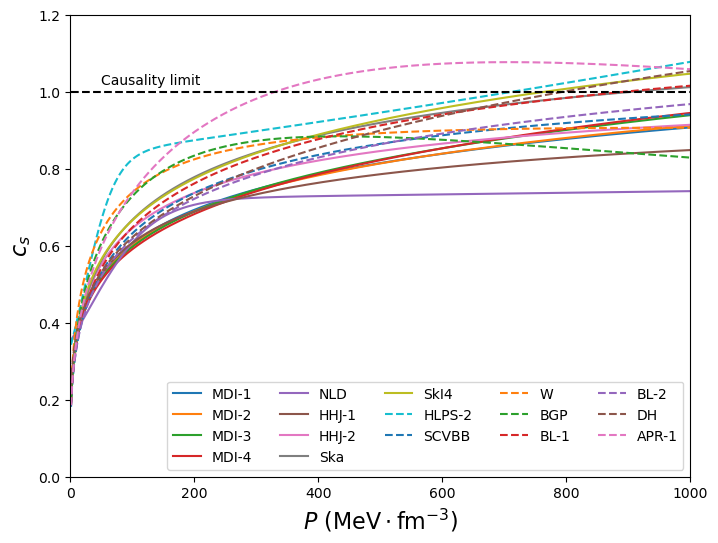

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
for i, (c_s, label) in enumerate(zip(sqrt_dP_dE, labels)):
    if i < len(functions) / 2:
        plt.plot(pressure_values, c_s, '-', label=label)
    else:
        plt.plot(pressure_values, c_s, '--', label=label)
    # Check if any value exceeds c and print the function name and pressure
    exceeds_limit = np.where(c_s > 1)[0]
    if exceeds_limit.size > 0:
        pressure_exceeding = pressure_values[exceeds_limit[0]]
        print(f"{label} violates causality limit at P = {pressure_exceeding:.2f} [MeV fm^-3]")
caus_limit = np.ones_like(pressure_values)
ax.plot(pressure_values, caus_limit, label='_nolegend_', color='k', linestyle='--')
plt.text(50, 1.02, 'Causality limit', color='k', size='medium')
plt.xlabel(r'$P \ \rm{(MeV \cdot fm^{-3})}$', fontsize=16)
plt.ylabel(r'$c_s$', fontsize=16)
plt.ylim(0, 1.2)
plt.xlim(0, 1000)
plt.legend(ncol=5, loc="lower right")
plt.show()

| Hadronic EOS | $P_{c_s=1}$ | $P_{M_{\max}}$ |
| ----------- | ----------: | -------------: |
| Ska         |      910.75 |         684.43 |
| Sk14        |      767.93 |         708.41 |
| HLPS-2      |      715.12 |         660.45 |
| BL-1        |      897.55 |         804.33 |
| DH          |      796.73 |         768.36 |
| **APR-1**   |  **332.26** |     **900.25** |

**Table:** Neutron EOS that violate the causality condition. Pressures are given in units of MeV fm$^{-3}$. EOS highlighted in bold satisfy $P_{c_s=1}<P_{M_{\max}}$.

```
```


Most of the EOS violate the causality condition only at central densities corresponding to configurations beyond the maximum-mass point. Since these solutions lie on the unstable branch of the mass–radius relation, the causality violation does not affect the physically relevant stable neutron star configurations.

## 4. Outlook for a Follow-up Seminar

Several observational constraints that favor low-radius and low-mass neutron star configurations are difficult to reconcile with purely hadronic EOS. In this context, quark matter and hybrid EOS provide a possible solution.

In a follow-up seminar, we could discuss quark stars and how they differ from purely hadronic neutron stars, as well as hybrid stars that contain both hadronic and deconfined quark phases. We could also explore how to construct hybrid equations of state and compute the corresponding stellar structure and mass–radius relations.